<a href="https://colab.research.google.com/github/dhouhaelaouni/image-steganography-system-/blob/main/image_stagnography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading image and libreries

In [120]:
!pip install pillow

from PIL import Image
from google.colab import files
import math
import matplotlib.pyplot as plt
import os



XOR Encryption

 Note: XOR with a repeating key is a simple cipher used here for demonstration. In production, AES would be used

In [121]:
def xor_encrypt(message, key):
    return ''.join(chr(ord(message[i]) ^ ord(key[i % len(key)])) for i in range(len(message)))

Binary conversion

In [122]:
def text_to_binary(text):
    return ''.join(format(ord(c), '08b') for c in text)

def binary_to_text(binary):
    chars = [binary[i:i+8] for i in range(0, len(binary), 8)]
    return ''.join(chr(int(c, 2)) for c in chars)



PSNR: measures how different the stego image is from the original.

Above 40 dB = invisible to the human eye

In [123]:
def calculate_psnr(original_path, stego_path):
    original = Image.open(original_path).convert("RGB")
    stego = Image.open(stego_path).convert("RGB")

    orig_pixels = list(original.getdata())
    stego_pixels = list(stego.getdata())

    mse = sum(
        (o[c] - s[c]) ** 2
        for o, s in zip(orig_pixels, stego_pixels)
        for c in range(3)
    ) / (len(orig_pixels) * 3)

    if mse == 0:
        print("📊 PSNR: ∞ dB (images are perfectly identical)")
        return

    psnr = 10 * math.log10(255**2 / mse)
    print(f"📊 PSNR: {psnr:.2f} dB  (above 40 dB = imperceptible to the human eye)")
    if psnr >= 40:
        print("   ✅ Result: Changes are imperceptible to the human eye.")
    else:
        print("   ⚠️  Result: Changes may be visible — consider using a larger image.")




STEGANALYSIS: compares the pixel color distribution(histogram) of the original vs stego image

If the distributions are very similar, the hidden data is not causing obvious statistical anomalies.

In [124]:
def histogram_similarity(original_path, stego_path):
    original = Image.open(original_path).convert("RGB")
    stego    = Image.open(stego_path).convert("RGB")

    orig_pixels  = list(original.getdata())
    stego_pixels = list(stego.getdata())

    # Build a frequency count for each of the 256 possible
    # values across all three color channels (R, G, B)
    orig_hist  = [0] * 256
    stego_hist = [0] * 256

    for op, sp in zip(orig_pixels, stego_pixels):
        for c in range(3):
            orig_hist[op[c]]  += 1
            stego_hist[sp[c]] += 1

    # Measure how different the two histograms are using
    # the sum of absolute differences, then convert to a
    # similarity percentage (100% = identical distributions)
    total_values   = len(orig_pixels) * 3
    total_diff     = sum(abs(orig_hist[i] - stego_hist[i]) for i in range(256))
    similarity_pct = (1 - total_diff / (2 * total_values)) * 100
    print(f"   📈 Histogram Similarity : {similarity_pct:.2f}%")
    if similarity_pct >= 99.0:
        print("   ✅ Result: No statistically detectable anomaly.")
    elif similarity_pct >= 95.0:
        print("   ⚠️  Result: Minor difference — acceptable for LSB embedding.")
    else:
        print("   ❌ Result: Notable difference — try a larger image.")


Visual Comparison

In [125]:
def show_comparison(original_path, stego_path):
    original = Image.open(original_path).convert("RGB")
    stego    = Image.open(stego_path).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(stego)
    axes[1].set_title("Stego Image (message hidden inside)", fontsize=13)
    axes[1].axis("off")

    plt.suptitle("Visual Comparison — Can you spot the difference?", fontsize=14)
    plt.tight_layout()
    plt.show()


Encode : hidding the message inside the image

In [126]:
def encode_image(image_path, message, key, output_path):
    image = Image.open(image_path).convert("RGB")
    pixels = list(image.getdata())

    # Encrypt the message then add the stop marker
    encrypted = xor_encrypt(message, key)+ "###END###"
    binary_message = text_to_binary(encrypted)

    # Check the message fits inside the image
    max_bits = len(pixels) * 3
    required_bits = len(binary_message)
    print(f"📦 Image capacity : {max_bits // 8} characters")
    print(f"📨 Message needs  : {required_bits // 8} characters")

    if required_bits > max_bits:
        raise ValueError("❌ Message is too long for this image. Use a larger image or a shorter message.")

    # Embed each bit of the message into the LSB of each color channel
    new_pixels = []
    msg_index = 0

    for pixel in pixels:
        r, g, b = pixel

        if msg_index < len(binary_message):
            r = (r & ~1) | int(binary_message[msg_index])
            msg_index += 1

        if msg_index < len(binary_message):
            g = (g & ~1) | int(binary_message[msg_index])
            msg_index += 1

        if msg_index < len(binary_message):
            b = (b & ~1) | int(binary_message[msg_index])
            msg_index += 1

        new_pixels.append((r, g, b))

    image.putdata(new_pixels)

    # Save as PNG — JPEG compression would destroy the hidden bits
    print("💾 Saving as PNG (lossless) — JPEG compression would destroy the hidden bits.")
    image.save(output_path)
    print("✅ Message encoded successfully!")

Decode : Extract the hidden message from the image

In [127]:
def decode_image(image_path, key):
    image = Image.open(image_path).convert("RGB")
    pixels = list(image.getdata())

    # Read the LSB of every color channel back into a binary string
    binary_data = ""
    for pixel in pixels:
        r, g, b = pixel
        binary_data += str(r & 1)
        binary_data += str(g & 1)
        binary_data += str(b & 1)

    # Convert binary back to characters, stop when we hit ###END###
    all_bytes = [binary_data[i:i+8] for i in range(0, len(binary_data), 8)]

    raw_message = ""
    for byte in all_bytes:
        char = chr(int(byte, 2))
        raw_message += char
        if "###END###" in raw_message:
            break

    # FIX: cut everything at the stop marker before decrypting
    if "###END###" not in raw_message:
        print("❌ No hidden message found, or wrong password.")
        return

    clean_message = raw_message[:raw_message.index("###END###")]
    decrypted = xor_encrypt(clean_message, key)
    print("🔓 Hidden message:", decrypted)


Main flow

  IT360 — Image Steganography System
  Tunis Business School | 2025-2026

📤 Step 1: Upload your cover image


Saving bird.jpg to bird (8).jpg
   Image loaded: bird (8).jpg

Enter your secret message : The quick brown fox jumps over the lazy dog at exactly 1245 AM while secret agent 007 monitors the secure uplink IP 192.168.1.254). Data security is paramount therefore we must implement AES256 bit protocols immediately Do you believe that asymmetric cryptography-utilizing both public and private keys-is fundamentally more secure than symmetric methods? Let us verify this hypothesis by processing approximately \(1,250,000 worth of digital transactions across multiple international nodes. Please note that special characters like ~, @, #, \), %, ^, &, *, (, ), _, and + must not cause any buffer overflows or encoding errors during the cryptographic transformation. If this entire test string successfully converts into unreadable ciphertext and then reverts perfectly back into this exact readable format, your encryption system is functioning correctly.
Enter password            : dhouha

🔒 Step 2: Enc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🖼️  Step 4: Visual comparison — original vs stego image


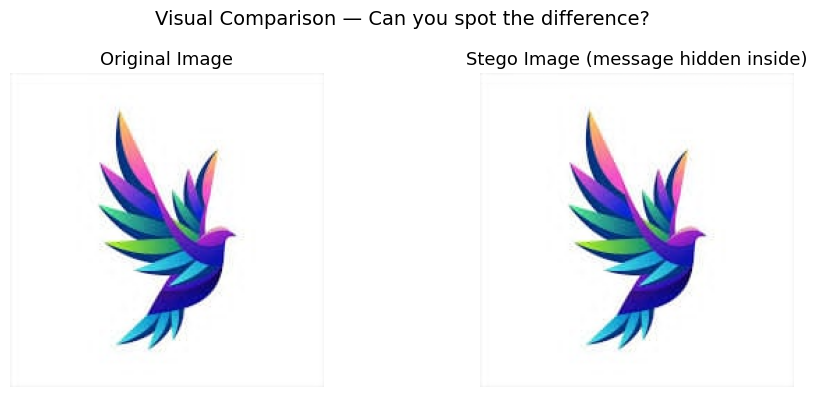


📐 Step 5: Image quality measurement (PSNR)
📊 PSNR: 63.68 dB  (above 40 dB = imperceptible to the human eye)
   ✅ Result: Changes are imperceptible to the human eye.

🔬 Step 6: Steganalysis — histogram similarity test
   📈 Histogram Similarity : 97.85%
   ⚠️  Result: Minor difference — acceptable for LSB embedding.

🔍 Step 7: Decoding to verify message integrity...
🔓 Hidden message: The quick brown fox jumps over the lazy dog at exactly 1245 AM while secret agent 007 monitors the secure uplink IP 192.168.1.254). Data security is paramount therefore we must implement AES256 bit protocols immediately Do you believe that asymmetric cryptography-utilizing both public and private keys-is fundamentally more secure than symmetric methods? Let us verify this hypothesis by processing approximately \(1,250,000 worth of digital transactions across multiple international nodes. Please note that special characters like ~, @, #, \), %, ^, &, *, (, ), _, and + must not cause any buffer overflows or e

In [128]:

print("=" * 55)
print("  IT360 — Image Steganography System")
print("  Tunis Business School | 2025-2026")
print("=" * 55)

# --- Upload ---
print("\n📤 Step 1: Upload your cover image")
uploaded   = files.upload()
image_name = list(uploaded.keys())[0]
print(f"   Image loaded: {image_name}")

# --- Inputs ---
message = input("\nEnter your secret message : ")
key     = input("Enter password            : ")

output_image = os.path.splitext(image_name)[0] + "_stego.png"

# --- Step 2: Encode ---
print("\n🔒 Step 2: Encoding message into image...")
encode_image(image_name, message, key, output_image)

# --- Step 3: Download ---
print("\n📥 Step 3: Downloading stego image...")
files.download(output_image)

# --- Step 4: Visual Comparison ---
print("\n🖼️  Step 4: Visual comparison — original vs stego image")
show_comparison(image_name, output_image)

# --- Step 5: PSNR ---
print("\n📐 Step 5: Image quality measurement (PSNR)")
calculate_psnr(image_name, output_image)

# --- Step 6: Steganalysis ---
print("\n🔬 Step 6: Steganalysis — histogram similarity test")
histogram_similarity(image_name, output_image)

# --- Step 7: Decode ---
print("\n🔍 Step 7: Decoding to verify message integrity...")
decode_image(output_image, key)

print("\n" + "=" * 55)
print("  All steps completed successfully.")
print("=" * 55)